# 2-1

## 2-1-1

In [107]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Download S&P 500 data
df = yf.download("^GSPC", start="2000-01-01", auto_adjust=False)

# Reset index to expose Date as a column
df = df.reset_index()


[*********************100%***********************]  1 of 1 completed


In [108]:
df.columns = df.columns.droplevel(1)

print(df.columns.tolist())


['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


In [109]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


In [110]:
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)


In [111]:
df["Day_sin"] = np.sin(2 * np.pi * df["Day"] / 31)
df["Day_cos"] = np.cos(2 * np.pi * df["Day"] / 31)


In [112]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["Year_scaled"] = scaler.fit_transform(df[["Year"]])


In [113]:
df


Price,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Day,Month_sin,Month_cos,Day_sin,Day_cos,Year_scaled
0,2000-01-03,1455.219971,1455.219971,1478.000000,1438.359985,1469.250000,931800000,2000,1,3,5.000000e-01,0.866025,0.571268,0.820763,0.0
1,2000-01-04,1399.420044,1399.420044,1455.219971,1397.430054,1455.219971,1009000000,2000,1,4,5.000000e-01,0.866025,0.724793,0.688967,0.0
2,2000-01-05,1402.109985,1402.109985,1413.270020,1377.680054,1399.420044,1085500000,2000,1,5,5.000000e-01,0.866025,0.848644,0.528964,0.0
3,2000-01-06,1403.449951,1403.449951,1411.900024,1392.099976,1402.109985,1092300000,2000,1,6,5.000000e-01,0.866025,0.937752,0.347305,0.0
4,2000-01-07,1441.469971,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,2000,1,7,5.000000e-01,0.866025,0.988468,0.151428,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6531,2025-12-19,6834.500000,6834.500000,6840.020020,6792.620117,6792.620117,8554470000,2025,12,19,-2.449294e-16,1.000000,-0.651372,-0.758758,1.0
6532,2025-12-22,6878.490234,6878.490234,6882.029785,6855.740234,6865.209961,4465030000,2025,12,22,-2.449294e-16,1.000000,-0.968077,-0.250653,1.0
6533,2025-12-23,6909.790039,6909.790039,6910.879883,6868.810059,6872.410156,3820560000,2025,12,23,-2.449294e-16,1.000000,-0.998717,-0.050649,1.0
6534,2025-12-24,6932.049805,6932.049805,6937.319824,6904.910156,6904.910156,1798270000,2025,12,24,-2.449294e-16,1.000000,-0.988468,0.151428,1.0


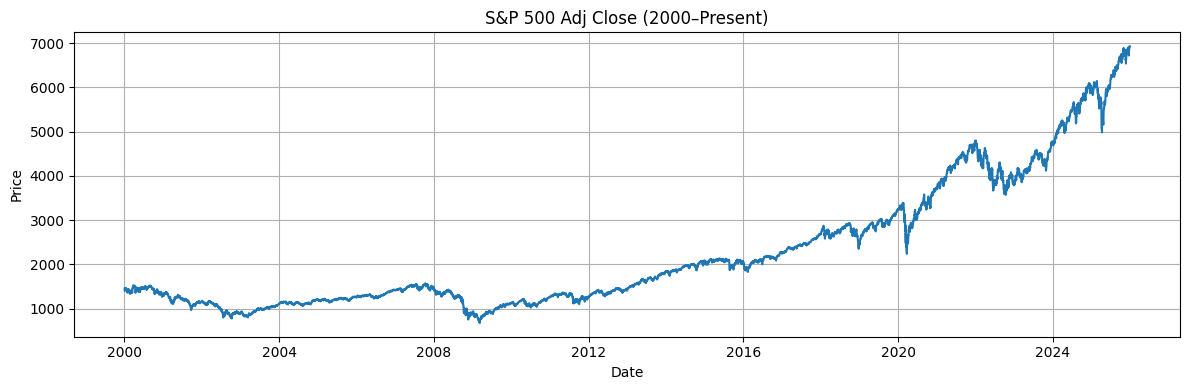

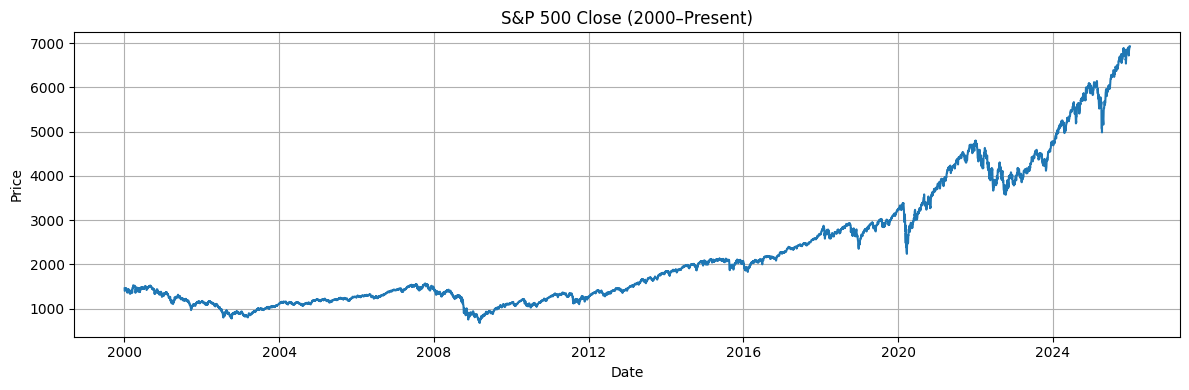

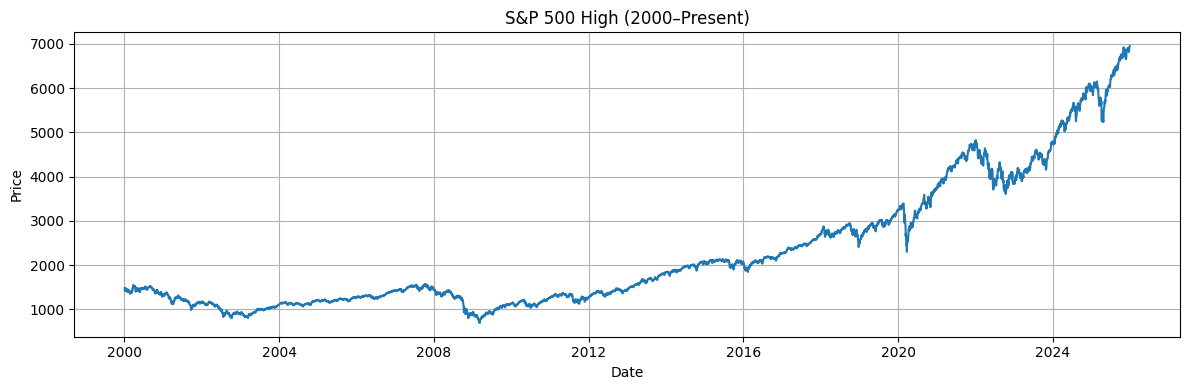

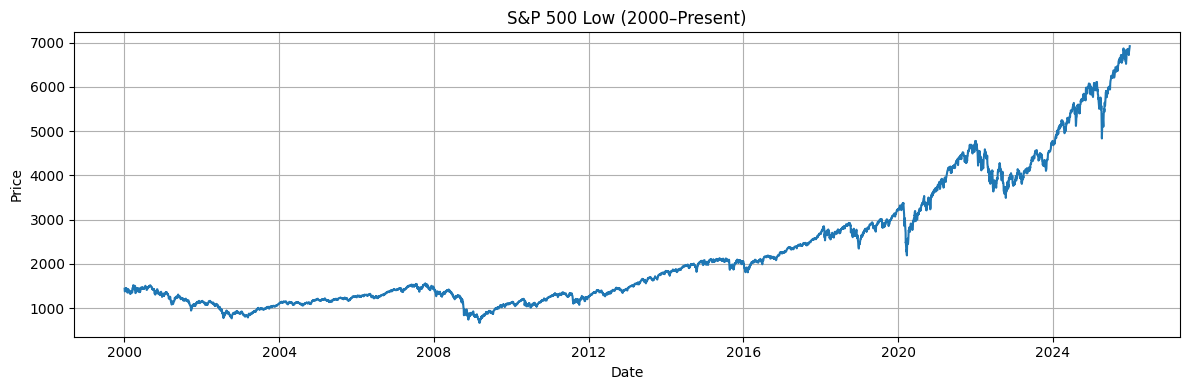

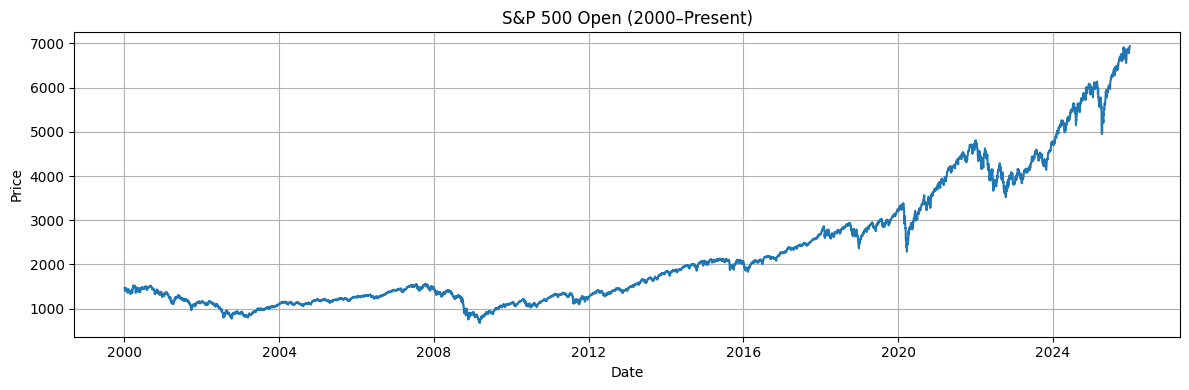

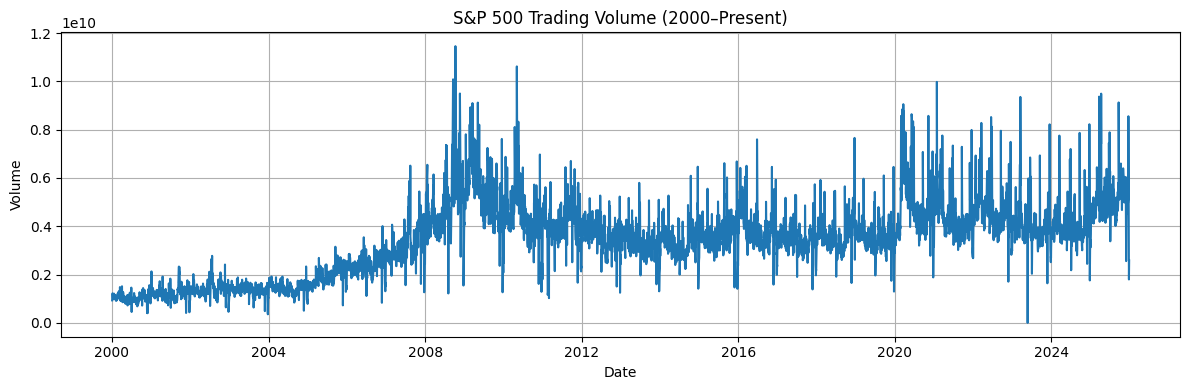

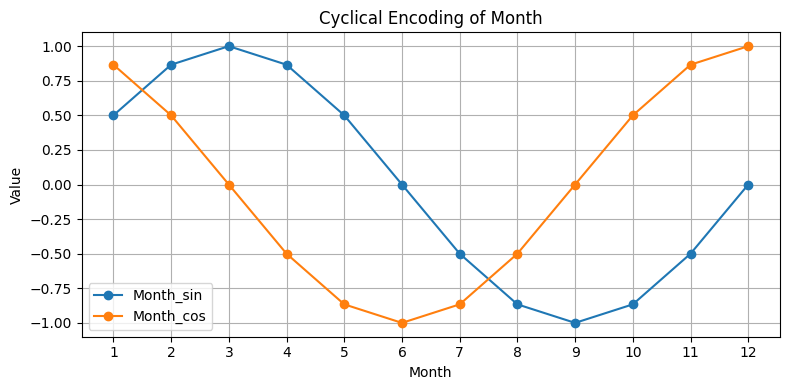

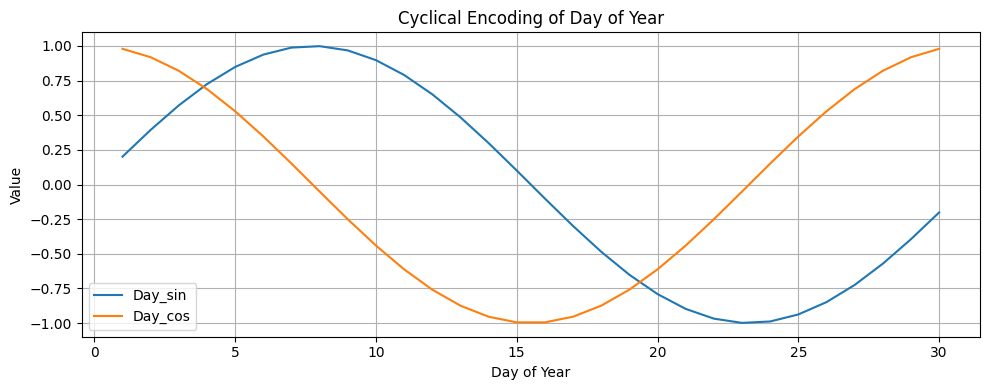

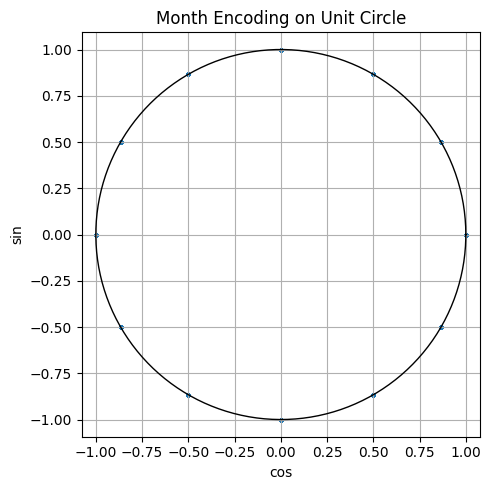

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. PRICE & VOLUME TIME SERIES
# -----------------------------
price_features = ["Adj Close", "Close", "High", "Low", "Open", "Volume"]

for feature in price_features:
    plt.figure(figsize=(12, 4))
    plt.plot(df["Date"], df[feature])

    if feature == "Volume":
        plt.title("S&P 500 Trading Volume (2000–Present)")
        plt.ylabel("Volume")
    else:
        plt.title(f"S&P 500 {feature} (2000–Present)")
        plt.ylabel("Price")

    plt.xlabel("Date")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --------------------------------
# 2. MONTH CYCLICAL ENCODING PLOT
# --------------------------------
month = np.arange(1, 13)

plt.figure(figsize=(8, 4))
plt.plot(month, np.sin(2 * np.pi * month / 12), marker="o", label="Month_sin")
plt.plot(month, np.cos(2 * np.pi * month / 12), marker="o", label="Month_cos")

plt.xticks(month)
plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Month")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------------
# 3. DAY-OF-YEAR CYCLICAL ENCODING
# -----------------------------------
day = np.arange(1, 31)

plt.figure(figsize=(10, 4))
plt.plot(day, np.sin(2 * np.pi * day / 31), label="Day_sin")
plt.plot(day, np.cos(2 * np.pi * day / 31), label="Day_cos")

plt.xlabel("Day of Year")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Day of Year")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------------
# 4. UNIT CIRCLE (INTUITION PLOT)
# -----------------------------------
theta = np.linspace(0, 2 * np.pi, 300)

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1)
plt.scatter(df["Month_cos"], df["Month_sin"], s=4, alpha=0.3)

plt.xlabel("cos")
plt.ylabel("sin")
plt.title("Month Encoding on Unit Circle")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()


### 2-1-2

<Figure size 1200x400 with 0 Axes>

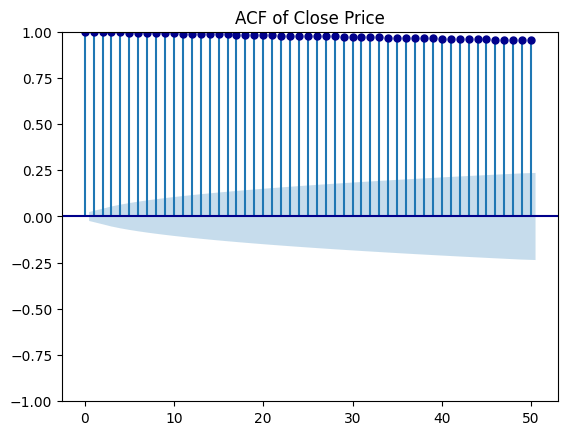

<Figure size 1200x400 with 0 Axes>

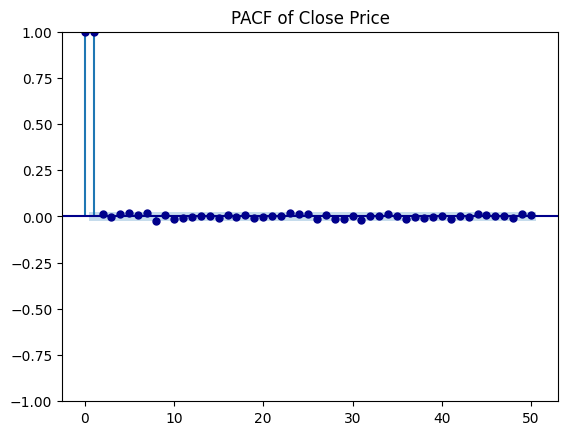

In [115]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df["Close"]



plt.figure(figsize=(12,4))
plot_acf(series, lags=50, alpha=0.05, color="darkblue")
plt.title("ACF of Close Price")
plt.show()



plt.figure(figsize=(12,4))
plot_pacf(series, lags=50, alpha=0.05, color="darkblue")
plt.title("PACF of Close Price")
plt.show()



<Figure size 1200x400 with 0 Axes>

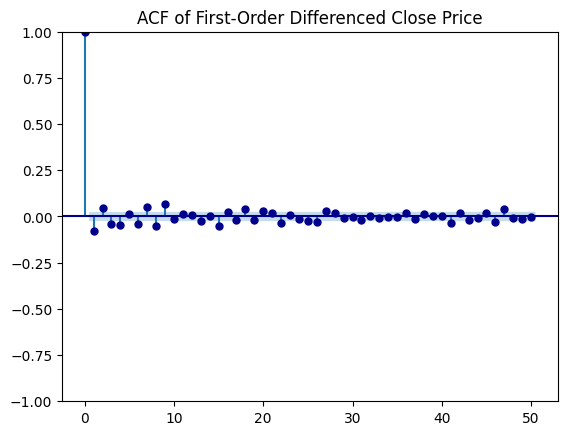

<Figure size 1200x400 with 0 Axes>

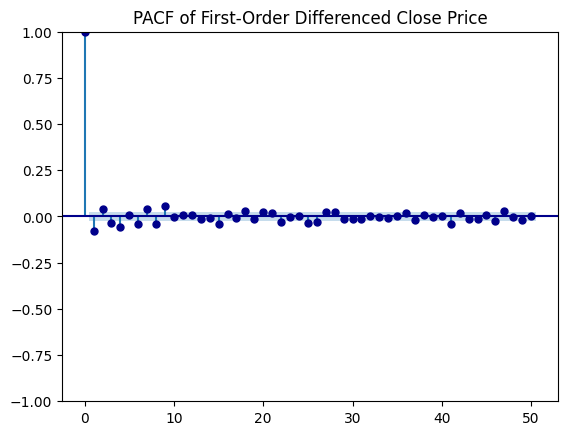

In [116]:
diff1 = series.diff().dropna()
plt.figure(figsize=(12,4))
plot_acf(diff1, lags=50, alpha=0.05, color="darkblue")
plt.title("ACF of First-Order Differenced Close Price")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(diff1, lags=50, alpha=0.05, color="darkblue")
plt.title("PACF of First-Order Differenced Close Price")
plt.show()


In [117]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.6f}")
    print("-" * 40)

# Original series
adf_test(series, "Original Close Price")

# First difference
adf_test(diff1, "1st Difference")




ADF Test for Original Close Price
ADF Statistic : 2.9819
p-value       : 1.000000
----------------------------------------
ADF Test for 1st Difference
ADF Statistic : -15.5471
p-value       : 0.000000
----------------------------------------


In [118]:
import numpy as np
from statsmodels.tsa.stattools import acf, pacf

# confidence bound
conf = 1.96 / np.sqrt(len(series))

# compute acf / pacf
acf_vals  = acf(series, nlags=100)
pacf_vals = pacf(series, nlags=100)

# lags index
lags = np.arange(len(acf_vals))

# significant lags (exclude lag 0)
significant_acf = lags[(np.abs(acf_vals) > conf) & (lags != 0)]
significant_pacf = lags[(np.abs(pacf_vals) > conf) & (lags != 0)]

print("Significant ACF lags(orginal):", significant_acf)
print("Significant PACF lags(orginal):", significant_pacf)


Significant ACF lags(orginal): [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
Significant PACF lags(orginal): [ 1  8 55]


In [119]:
import numpy as np
from statsmodels.tsa.stattools import acf, pacf

# confidence bound
conf = 1.96 / np.sqrt(len(diff1))

# compute acf / pacf
acf_vals  = acf(diff1, nlags=100)
pacf_vals = pacf(diff1, nlags=100)

# lags index
lags = np.arange(len(acf_vals))

# significant lags (exclude lag 0)
significant_acf = lags[(np.abs(acf_vals) > conf) & (lags != 0)]
significant_pacf = lags[(np.abs(pacf_vals) > conf) & (lags != 0)]

print("Significant ACF lags(diff1):", significant_acf)
print("Significant PACF lags(diff1):", significant_pacf)


Significant ACF lags(diff1): [ 1  2  3  4  6  7  8  9 15 16 18 20 22 26 27 41 46 47 62 63 81 82 87 91
 96 97]
Significant PACF lags(diff1): [ 1  2  3  4  6  7  8  9 15 18 20 22 25 26 41 47 53 56 62 71 73 82 84 87
 89 91 96 97]


### 2-1-4

In [120]:
df["Close_diff"] = df["Close"].diff()
df["Open_diff"] = df["Open"].diff()
df["High_diff"] = df["High"].diff()
df["Low_diff"] = df["Low"].diff()

In [121]:
df = df.dropna().reset_index(drop=True)
df["Volume"] = np.log1p(df["Volume"])



df['price_change'] = df['Close'] - df['Open']
df['price_volume_interaction'] = df['price_change'] * df['Volume']
df['high_low_ratio'] = df['High'] / df['Low']

In [122]:
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Day,...,Day_sin,Day_cos,Year_scaled,Close_diff,Open_diff,High_diff,Low_diff,price_change,price_volume_interaction,high_low_ratio
0,2000-01-04,1399.420044,1399.420044,1455.219971,1397.430054,1455.219971,20.732226,2000,1,4,...,0.724793,0.688967,0.0,-55.799927,-14.030029,-22.780029,-40.929932,-55.799927,-1156.856669,1.041354
1,2000-01-05,1402.109985,1402.109985,1413.270020,1377.680054,1399.420044,20.805307,2000,1,5,...,0.848644,0.528964,0.0,2.689941,-55.799927,-41.949951,-19.750000,2.689941,55.965056,1.025833
2,2000-01-06,1403.449951,1403.449951,1411.900024,1392.099976,1402.109985,20.811551,2000,1,6,...,0.937752,0.347305,0.0,1.339966,2.689941,-1.369995,14.419922,1.339966,27.886768,1.014223
3,2000-01-07,1441.469971,1441.469971,1441.469971,1400.729980,1403.449951,20.926370,2000,1,7,...,0.988468,0.151428,0.0,38.020020,1.339966,29.569946,8.630005,38.020020,795.620994,1.029085
4,2000-01-10,1457.599976,1457.599976,1464.359985,1441.469971,1441.469971,20.786053,2000,1,10,...,0.897805,-0.440394,0.0,16.130005,38.020020,22.890015,40.739990,16.130005,335.279134,1.015880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6530,2025-12-19,6834.500000,6834.500000,6840.020020,6792.620117,6792.620117,22.869720,2025,12,19,...,-0.651372,-0.758758,1.0,59.740234,14.560059,23.890137,34.120117,41.879883,957.781185,1.006978
6531,2025-12-22,6878.490234,6878.490234,6882.029785,6855.740234,6865.209961,22.219542,2025,12,22,...,-0.968077,-0.250653,1.0,43.990234,72.589844,42.009766,63.120117,13.280273,295.081590,1.003835
6532,2025-12-23,6909.790039,6909.790039,6910.879883,6868.810059,6872.410156,22.063663,2025,12,23,...,-0.998717,-0.050649,1.0,31.299805,7.200195,28.850098,13.069824,37.379883,824.737132,1.006125
6533,2025-12-24,6932.049805,6932.049805,6937.319824,6904.910156,6904.910156,21.310091,2025,12,24,...,-0.988468,0.151428,1.0,22.259766,32.500000,26.439941,36.100098,27.139648,578.348376,1.004694


In [123]:
import numpy as np

# ==============================
# Parameters
# ==============================
INPUT_WINDOW  = 9
OUTPUT_WINDOW = 1

# ==============================
# Input features (X)
# ==============================
input_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Month_sin",
    "Month_cos",
    "Day_sin",
    "Day_cos",
    'price_volume_interaction',
    'high_low_ratio',

    
]

X_data = df[input_cols].values     # (T, num_input_features)

# ==============================
# Output features (Y) — OHLC
# ==============================
output_cols = ["Open", "High", "Low", "Close"]
Y_data = df[output_cols].values    # (T, 4)

# ==============================
# Build windows
# ==============================
X, Y = [], []

for i in range(INPUT_WINDOW, len(df) - OUTPUT_WINDOW):
    # Input window
    X.append(
        X_data[i - INPUT_WINDOW : i, :]
    )  # (INPUT_WINDOW, num_input_features)

    # Output window (future OHLC)
    Y.append(
        Y_data[i : i + OUTPUT_WINDOW, :]
    )  # (OUTPUT_WINDOW, 4)

X = np.array(X)
Y = np.array(Y)

# ==============================
# Shapes check
# ==============================
print("X shape:", X.shape)
print("Y shape:", Y.shape)


df_test_2024 = df[(df["Date"] >= "2024-01-01") & (df["Date"] <= "2025-12-31")]
test_2024 = list(df_test_2024.index)
test_2024 = df_test_2024.index[df_test_2024.index < X.shape[0]].tolist()






X shape: (6525, 9, 10)
Y shape: (6525, 1, 4)


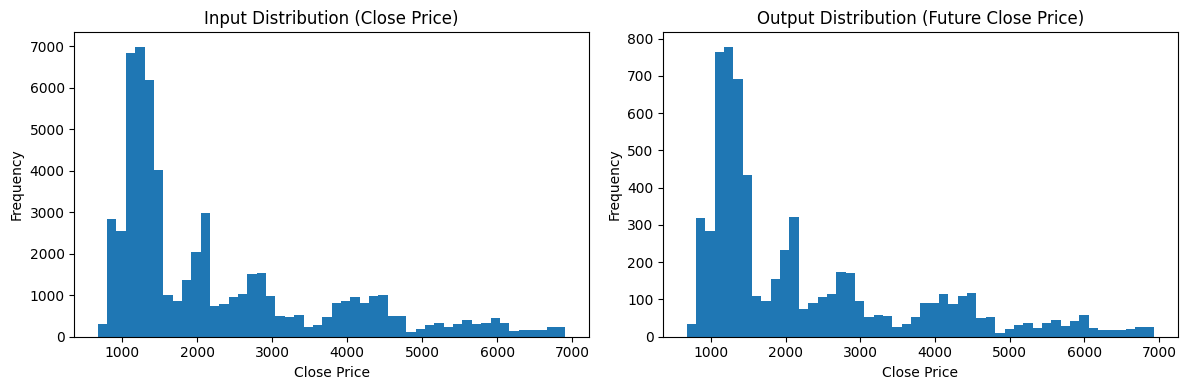

In [124]:
import matplotlib.pyplot as plt

# --- Input Close ---
close_index = input_cols.index("Close")
X_close_flat = X[:, :, close_index].reshape(-1)

# --- Output Close ---
close_out_index = output_cols.index("Close")
Y_close_flat = Y[:, :, close_out_index].reshape(-1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(X_close_flat, bins=50)
plt.title("Input Distribution (Close Price)")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(Y_close_flat, bins=50)
plt.title("Output Distribution (Future Close Price)")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [125]:
import numpy as np
import pandas as pd

N = len(Y)

train_size = int(0.70 * N)
val_size   = int(0.20 * N)
test_size  = N - train_size - val_size  # ensures total = N

# Indices (time-ordered, no overlap)
train_indices = np.arange(0, train_size)
val_indices   = np.arange(train_size, train_size + val_size)
test_indices  = np.arange(train_size + val_size, N)
# Split data
X_train, Y_train = X[train_indices], Y[train_indices]
X_val,   Y_val   = X[val_indices],   Y[val_indices]
X_test,  Y_test  = X[test_indices],  Y[test_indices]
X_2024, Y_2024 = X[test_2024],  Y[test_2024]

# Flatten Y to 2D (samples, features)
Y_train = Y_train[:, 0, :]
Y_val   = Y_val[:, 0, :]
Y_test  = Y_test[:, 0, :]
Y_2024  = Y_2024[:, 0, :]


print("Y_train shape:", Y_train.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)
print("Y_2024 shape:", Y_2024.shape)



print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("X_2024 shape:", X_2024.shape)


Y_train shape: (4567, 4)
Y_val shape: (1305, 4)
Y_test shape: (653, 4)
Y_2024 shape: (489, 4)
X_train shape: (4567, 9, 10)
X_val shape: (1305, 9, 10)
X_test shape: (653, 9, 10)
X_2024 shape: (489, 9, 10)


In [126]:
from sklearn.preprocessing import StandardScaler

# ---------- X scaler ----------
x_scaler = StandardScaler()

# Fit ONLY on training data
X_train_2d = X_train.reshape(-1, X_train.shape[-1])  # (N*T, F)
x_scaler.fit(X_train_2d)

# Transform
X_train_z = x_scaler.transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_val_z = x_scaler.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

X_test_z = x_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

X_2024_z = x_scaler.transform(
    X_2024.reshape(-1, X_2024.shape[-1])
).reshape(X_2024.shape)



# ---------- Y scaler ----------
y_scaler = StandardScaler()

y_scaler.fit(Y_train)   # train only

Y_train_z = y_scaler.transform(Y_train)
Y_val_z   = y_scaler.transform(Y_val)
Y_test_z  = y_scaler.transform(Y_test)
Y_2024_z  = y_scaler.transform(Y_2024)





# Check mean and std
print("X_train_z mean:", X_train_z.mean(axis=(0,1)))
print("X_train_z std :", X_train_z.std(axis=(0,1)))
print("Y_train_z mean:", Y_train_z.mean(axis=0))
print("Y_train_z std :", Y_train_z.std(axis=0))





X_train_z mean: [ 5.33710892e-15 -8.05722151e-15  7.66013101e-15  2.80560703e-15
  3.80311417e-17  8.07561866e-15  2.51740228e-16  3.28759232e-15
  2.74712874e-16  3.58676331e-12]
X_train_z std : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Y_train_z mean: [ 5.97337424e-16 -5.61845293e-16  5.20032646e-16 -5.42883744e-16]
Y_train_z std : [1. 1. 1. 1.]


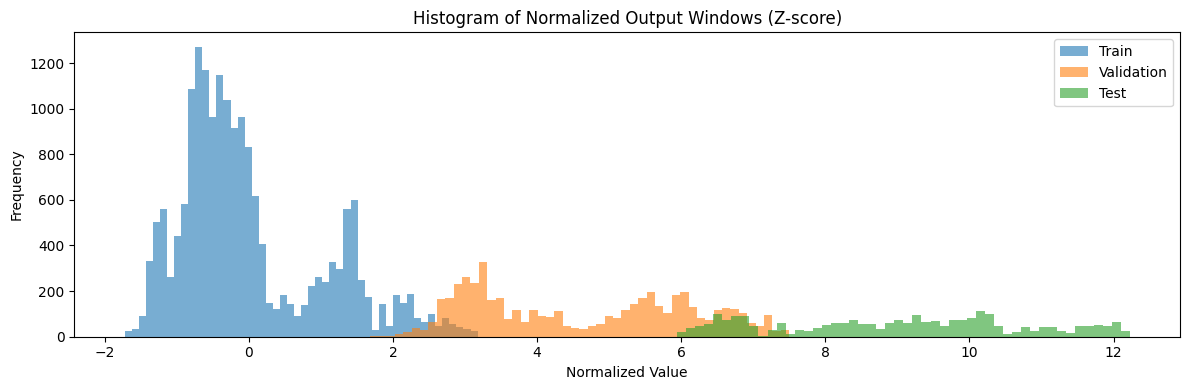

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.hist(Y_train_z.flatten(), bins=50, alpha=0.6, label="Train")
plt.hist(Y_val_z.flatten(),   bins=50, alpha=0.6, label="Validation")
plt.hist(Y_test_z.flatten(),  bins=50, alpha=0.6, label="Test")

plt.title("Histogram of Normalized Output Windows (Z-score)")
plt.xlabel("Normalized Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [128]:
import torch
from torch.utils.data import Dataset

class WindowDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


In [129]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    WindowDataset(X_train_z, Y_train_z),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=0
)

val_loader = DataLoader(
    WindowDataset(X_val_z, Y_val_z),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    WindowDataset(X_test_z, Y_test_z),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


last_year_loader = DataLoader(
    WindowDataset(X_2024_z, Y_2024_z),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

# 2-2

## 2-2-1

In [130]:
import torch

def rmse(y_pred, y_true):
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2))

def mae(y_pred, y_true):
    return torch.mean(torch.abs(y_pred - y_true))

def mape(y_pred, y_true, eps=1e-8):
    return torch.mean(torch.abs((y_true - y_pred) / (y_true + eps))) * 100

def r2_score_t(y_pred, y_true):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-8)


In [131]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(14,4))

    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(history["val_rmse"], label="RMSE")
    plt.plot(history["val_mae"], label="MAE")
    plt.plot(history["val_mape"], label="MAPE")
    plt.plot(history["val_r2"], label="R²")
    plt.legend()
    plt.title("Validation Metrics")

    plt.show()


In [132]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim



def train_model(model, train_loader, val_loader, num_epochs=100, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "val_loss": [],
        "train_rmse": [], "val_rmse": [],
        "train_mae": [], "val_mae": [],
        "train_mape": [], "val_mape": [],
        "train_r2": [], "val_r2": []
    }

    best_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    
    # --- START TIMER ---
    start_time = time.time()

    for epoch in range(num_epochs):

        # ========== TRAIN ==========
        model.train()
        train_loss = 0.0
        y_train_pred, y_train_true = [], []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device).squeeze(1)

            optimizer.zero_grad()
            y_hat = model(x)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            y_train_pred.append(y_hat.detach())
            y_train_true.append(y)

        y_train_pred = torch.cat(y_train_pred)
        y_train_true = torch.cat(y_train_true)

        train_loss /= len(train_loader.dataset)

        history["train_loss"].append(train_loss)
        history["train_rmse"].append(rmse(y_train_pred, y_train_true).item())
        history["train_mae"].append(mae(y_train_pred, y_train_true).item())
        history["train_mape"].append(mape(y_train_pred, y_train_true).item())
        history["train_r2"].append(r2_score_t(y_train_pred, y_train_true).item())

        # ========== VALIDATION ==========
        model.eval()
        val_loss = 0.0
        y_val_pred, y_val_true = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device).squeeze(1)

                y_hat = model(x)
                loss = criterion(y_hat, y)

                val_loss += loss.item() * x.size(0)
                y_val_pred.append(y_hat)
                y_val_true.append(y)

        y_val_pred = torch.cat(y_val_pred)
        y_val_true = torch.cat(y_val_true)

        val_loss /= len(val_loader.dataset)

        history["val_loss"].append(val_loss)
        history["val_rmse"].append(rmse(y_val_pred, y_val_true).item())
        history["val_mae"].append(mae(y_val_pred, y_val_true).item())
        history["val_mape"].append(mape(y_val_pred, y_val_true).item())
        history["val_r2"].append(r2_score_t(y_val_pred, y_val_true).item())

        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1:03d} | "
                f"Train Loss {train_loss:.4f} | "
                f"Val Loss {val_loss:.4f} | "
                f"Val R² {history['val_r2'][-1]:.3f}"
            )
            
    # --- END TIMER ---
    end_time = time.time()
    total_training_time = end_time - start_time
    # print(f"\nTraining Complete. Total Time: {total_training_time:.2f} seconds")

    model.load_state_dict(best_model_wts)
    
    # Return time as 3rd output
    return model, history, total_training_time

In [133]:
def plot_metric(history, train_key, val_key, title, ylabel):
    plt.figure(figsize=(6,4))
    plt.plot(history[train_key], label="Train")
    plt.plot(history[val_key], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [134]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dimensions based on your code
NUM_FEATURES = X.shape[-1]
SEQ_LEN = INPUT_WINDOW
OUTPUT_DIM = 4     # [Open, High, Low, Close]

# ==========================================
# 1. Baseline MLP
# ==========================================
class BaselineMLP(nn.Module):
    def __init__(self, num_features, seq_len, output_dim, hidden_dim=128):
        super(BaselineMLP, self).__init__()
        
        # Flatten input: (Batch, Seq_Len, Features) -> (Batch, Seq_Len * Features)
        self.input_dim = num_features * seq_len
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)
        

In [135]:
mlp_model = BaselineMLP(NUM_FEATURES, SEQ_LEN, OUTPUT_DIM)
print("--- Training MLP ---")

mlp_model, mlp_history,time_mlp = train_model(
    mlp_model,
    train_loader,
    val_loader,
    num_epochs=100
)


--- Training MLP ---
Epoch 010 | Train Loss 0.0437 | Val Loss 0.0554 | Val R² 0.974
Epoch 020 | Train Loss 0.0358 | Val Loss 0.0133 | Val R² 0.994
Epoch 030 | Train Loss 0.0348 | Val Loss 0.0411 | Val R² 0.981
Epoch 040 | Train Loss 0.0350 | Val Loss 0.1165 | Val R² 0.946
Epoch 050 | Train Loss 0.0331 | Val Loss 0.0762 | Val R² 0.965
Epoch 060 | Train Loss 0.0337 | Val Loss 0.0655 | Val R² 0.970
Epoch 070 | Train Loss 0.0316 | Val Loss 0.0168 | Val R² 0.992
Epoch 080 | Train Loss 0.0338 | Val Loss 0.2346 | Val R² 0.891
Epoch 090 | Train Loss 0.0325 | Val Loss 0.0327 | Val R² 0.985
Epoch 100 | Train Loss 0.0333 | Val Loss 0.0440 | Val R² 0.980


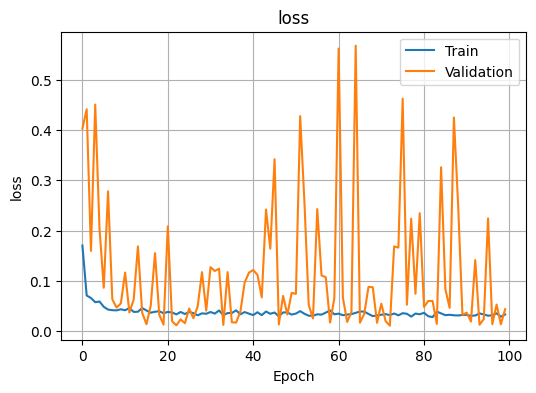

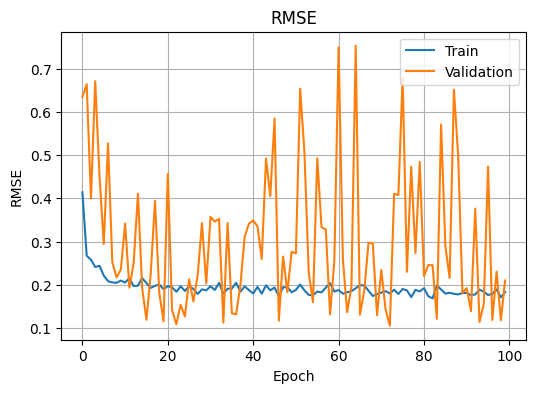

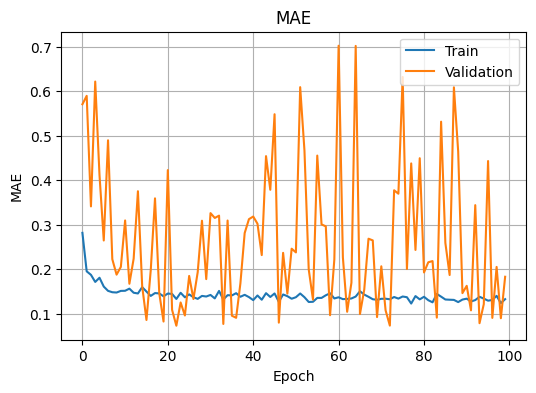

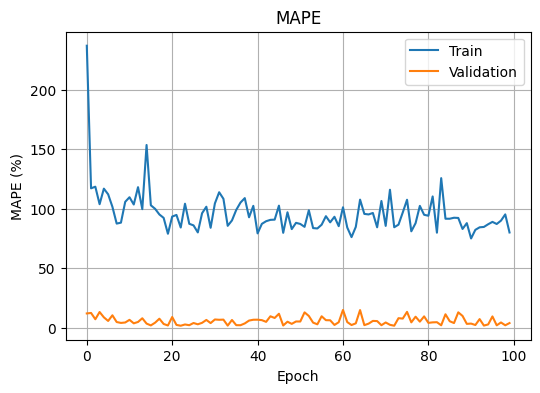

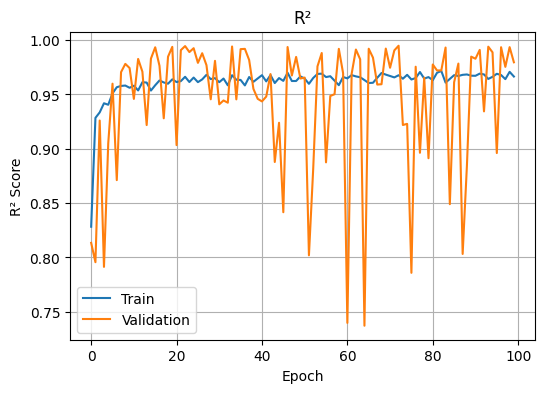

In [136]:
plot_metric(mlp_history, "train_loss", "val_loss", "loss", "loss")
plot_metric(mlp_history, "train_rmse", "val_rmse", "RMSE", "RMSE")
plot_metric(mlp_history, "train_mae",  "val_mae",  "MAE",  "MAE")
plot_metric(mlp_history, "train_mape","val_mape","MAPE","MAPE (%)")
plot_metric(mlp_history, "train_r2",  "val_r2",  "R²",   "R² Score")


### 2-2-2

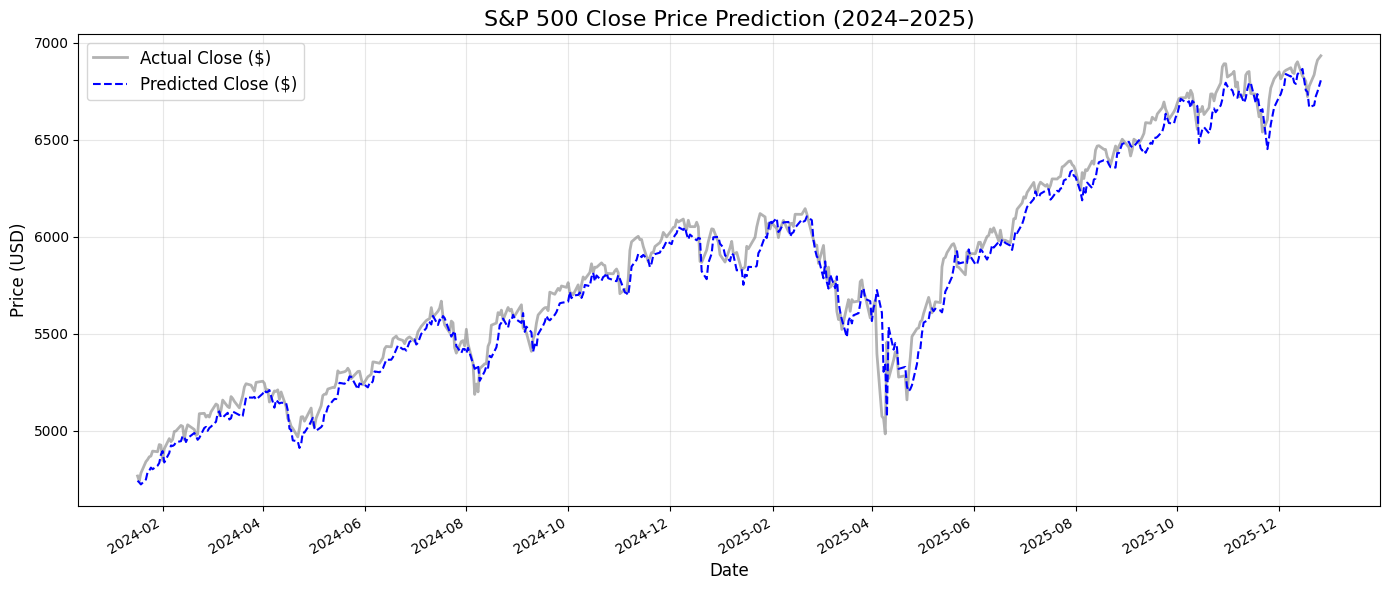

Samples plotted      : 489
Latest date          : 2025-12-26
Latest Actual Close  : $6932.05
Latest Pred Close    : $6805.39


In [137]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. Model Evaluation on Test (2024–2025)
# ==========================================
mlp_model.eval()

y_preds = []
y_trues = []

with torch.no_grad():
    for x, y in last_year_loader:
        x = x.to(device)
        y = y.to(device).squeeze(1)   # (B, 4)

        y_hat = mlp_model(x)          # (B, 4)

        y_preds.append(y_hat.cpu())
        y_trues.append(y.cpu())

# Concatenate batches
y_preds = torch.cat(y_preds, dim=0)  # (N, 4)
y_trues = torch.cat(y_trues, dim=0)  # (N, 4)

# ==========================================
# 2. Denormalize (Inverse Transform)
# ==========================================
# Convert to numpy for sklearn scaler
preds_scaled = y_preds.numpy()
trues_scaled = y_trues.numpy()

# Inverse scaling (expects shape [N, 4])
preds_real = y_scaler.inverse_transform(preds_scaled)
trues_real = y_scaler.inverse_transform(trues_scaled)

# Extract Close price (index 3)
pred_close = preds_real[:, 3]
true_close = trues_real[:, 3]

# ==========================================
# 3. Align Dates with Sliding Window Outputs
# ==========================================
# IMPORTANT:
# Each prediction corresponds to the END of a sliding window.
# Therefore, dates must be aligned to predictions.

# dates must come from the SAME df used to build last_year_loader
# Example:
dates = df_test_2024["Date"].reset_index(drop=True)

# Align length safely (robust to off-by-one)
dates = dates.iloc[-len(pred_close):]

# Final sanity check
assert len(dates) == len(pred_close), "Date / prediction length mismatch!"

# ==========================================
# 4. Plot: Actual vs Predicted Close (with Dates)
# ==========================================
plt.figure(figsize=(14, 6))

plt.plot(
    dates,
    true_close,
    label="Actual Close ($)",
    color="grey",
    alpha=0.6,
    linewidth=2
)

plt.plot(
    dates,
    pred_close,
    label="Predicted Close ($)",
    color="blue",
    linestyle="--",
    linewidth=1.5
)

plt.title("S&P 500 Close Price Prediction (2024–2025)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Beautify date axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# ==========================================
# 5. Verification Prints
# ==========================================
print(f"Samples plotted      : {len(pred_close)}")
print(f"Latest date          : {dates.iloc[-1].date()}")
print(f"Latest Actual Close  : ${true_close[-1]:.2f}")
print(f"Latest Pred Close    : ${pred_close[-1]:.2f}")


In [138]:
from torchinfo import summary

summary(
    mlp_model,
    input_size=(1, SEQ_LEN, NUM_FEATURES),
    device=device
)


Layer (type:depth-idx)                   Output Shape              Param #
BaselineMLP                              [1, 4]                    --
├─Sequential: 1-1                        [1, 4]                    --
│    └─Flatten: 2-1                      [1, 90]                   --
│    └─Linear: 2-2                       [1, 128]                  11,648
│    └─BatchNorm1d: 2-3                  [1, 128]                  256
│    └─ReLU: 2-4                         [1, 128]                  --
│    └─Dropout: 2-5                      [1, 128]                  --
│    └─Linear: 2-6                       [1, 64]                   8,256
│    └─BatchNorm1d: 2-7                  [1, 64]                   128
│    └─ReLU: 2-8                         [1, 64]                   --
│    └─Dropout: 2-9                      [1, 64]                   --
│    └─Linear: 2-10                      [1, 4]                    260
Total params: 20,548
Trainable params: 20,548
Non-trainable params: 0
Total

# 2-3

## 2-3-1

### 2-3-1-1

In [139]:
class CNN_LSTM(nn.Module):
    def __init__(self, num_features, hidden_dim=64, output_dim=4):
        super(CNN_LSTM, self).__init__()
        
        self.output_dim = output_dim   # <-- FIX
        
        # --- CNN ---
        self.cnn = nn.Conv1d(num_features, 64, kernel_size=3, padding=1)
        self.bn_cnn = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        
        # --- LSTM ---
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.bn_lstm = nn.BatchNorm1d(hidden_dim)
        
        # --- Output ---
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (Batch, Seq, Features)

        # 1. Residual baseline (last OHLC)
        last_price = x[:, -1, :self.output_dim]  # <-- FIX
        
        # 2. CNN
        x = x.permute(0, 2, 1)
        x = self.relu(self.bn_cnn(self.cnn(x)))
        
        # 3. LSTM
        x = x.permute(0, 2, 1)
        _, (h_n, _) = self.lstm(x)
        h_last = self.bn_lstm(h_n[-1])
        
        # 4. Delta prediction
        delta = self.fc(h_last)

        # return last_price
        # 5. Residual output
        return last_price + delta


### 2-3-1-2

In [140]:
lstm_model = CNN_LSTM(NUM_FEATURES, hidden_dim=64, output_dim=OUTPUT_DIM)
print("\n--- Training CNN-LSTM ---")

lstm_model, lstm_history,time_lstm = train_model(
    lstm_model,
    train_loader,
    val_loader,
    num_epochs=100
)





--- Training CNN-LSTM ---
Epoch 010 | Train Loss 0.0009 | Val Loss 0.0089 | Val R² 0.996
Epoch 020 | Train Loss 0.0008 | Val Loss 0.0066 | Val R² 0.997
Epoch 030 | Train Loss 0.0007 | Val Loss 0.0065 | Val R² 0.997
Epoch 040 | Train Loss 0.0007 | Val Loss 0.0065 | Val R² 0.997
Epoch 050 | Train Loss 0.0007 | Val Loss 0.0065 | Val R² 0.997
Epoch 060 | Train Loss 0.0006 | Val Loss 0.0067 | Val R² 0.997
Epoch 070 | Train Loss 0.0006 | Val Loss 0.0066 | Val R² 0.997
Epoch 080 | Train Loss 0.0006 | Val Loss 0.0069 | Val R² 0.997
Epoch 090 | Train Loss 0.0006 | Val Loss 0.0066 | Val R² 0.997
Epoch 100 | Train Loss 0.0006 | Val Loss 0.0064 | Val R² 0.997


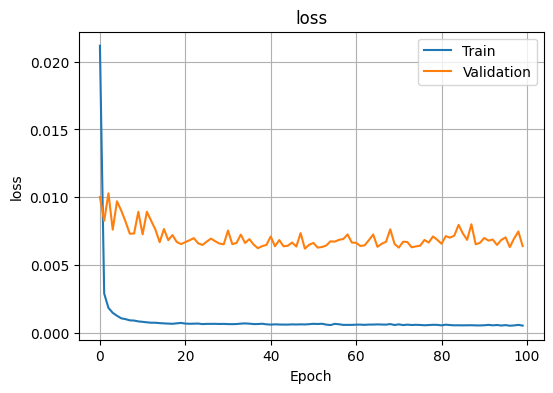

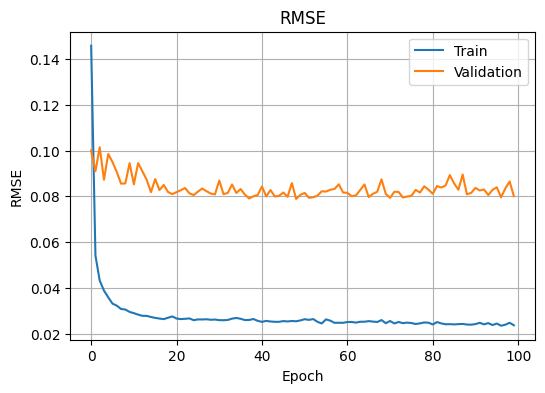

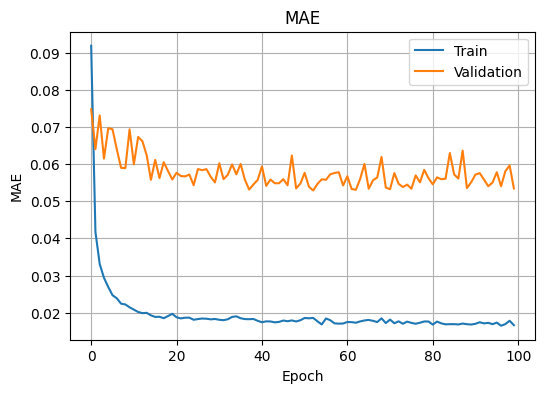

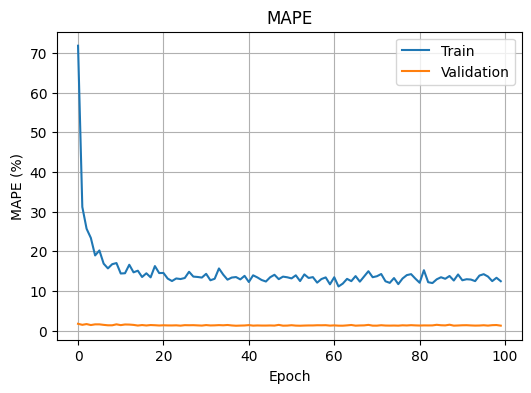

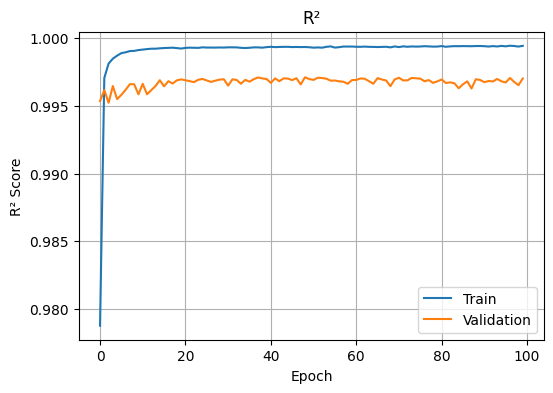

In [141]:
plot_metric(lstm_history, "train_loss", "val_loss", "loss", "loss")
plot_metric(lstm_history, "train_rmse", "val_rmse", "RMSE", "RMSE")
plot_metric(lstm_history, "train_mae",  "val_mae",  "MAE",  "MAE")
plot_metric(lstm_history, "train_mape","val_mape","MAPE","MAPE (%)")
plot_metric(lstm_history, "train_r2",  "val_r2",  "R²",   "R² Score")


In [142]:
summary(
    lstm_model,
    input_size=(1, SEQ_LEN, NUM_FEATURES),
    device=device
)


Layer (type:depth-idx)                   Output Shape              Param #
CNN_LSTM                                 [1, 4]                    --
├─Conv1d: 1-1                            [1, 64, 9]                1,984
├─BatchNorm1d: 1-2                       [1, 64, 9]                128
├─ReLU: 1-3                              [1, 64, 9]                --
├─LSTM: 1-4                              [1, 9, 64]                66,560
├─BatchNorm1d: 1-5                       [1, 64]                   128
├─Linear: 1-6                            [1, 4]                    260
Total params: 69,060
Trainable params: 69,060
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.62
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.28
Estimated Total Size (MB): 0.29

## 2-3-2

### 2-3-2-1

In [143]:
import torch
import torch.nn as nn

class CNN_GRU(nn.Module):
    def __init__(self, num_features, hidden_dim=64, output_dim=4):
        super(CNN_GRU, self).__init__()
        
        self.output_dim = output_dim
        
        # --- CNN Block ---
        # Matches: Conv1D (None, 30, 64)
        self.cnn = nn.Conv1d(in_channels=num_features, out_channels=64, kernel_size=3, padding=1)
        self.bn_cnn = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        
        # --- Stacked GRU Block ---
        # Matches:
        # GRU (None, 30, 64) -> Layer 1 (returns sequences)
        # GRU (None, 64)     -> Layer 2 (return sequences=False)
        self.gru = nn.GRU(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=2,        # Stacked GRU
            batch_first=True,
            dropout=0.2
        )
        self.bn_gru = nn.BatchNorm1d(hidden_dim)
        
        # --- Output Block ---
        # Matches: Dense (None, 1) -> Adapted to output_dim
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (Batch, Seq_Len, Features)

        # 1. Residual baseline (Last Known Price: High, Low, Open, Close)
        last_price = x[:, -1, :self.output_dim]
        
        # 2. CNN Forward
        x = x.permute(0, 2, 1)          # [Batch, Feat, Seq]
        x = self.relu(self.bn_cnn(self.cnn(x)))
        
        # 3. GRU Forward
        x = x.permute(0, 2, 1)          # [Batch, Seq, Feat]
        _, h_n = self.gru(x)
        
        # Take the last hidden state from the last layer (-1)
        h_last = h_n[-1]
        
        # Apply BatchNorm to hidden state
        h_last = self.bn_gru(h_last)
        
        # 4. Delta prediction
        delta = self.fc(h_last)
        
        # 5. Residual output
        return last_price + delta

### 2-3-2-2

In [144]:
gru_model = CNN_GRU(NUM_FEATURES, hidden_dim=64, output_dim=OUTPUT_DIM)
print("\n--- Training CNN-GRU ---")

gru_model, gru_history,time_gru = train_model(
    gru_model,
    train_loader,
    val_loader,
    num_epochs=100
)




--- Training CNN-GRU ---
Epoch 010 | Train Loss 0.0010 | Val Loss 0.0076 | Val R² 0.996
Epoch 020 | Train Loss 0.0008 | Val Loss 0.0070 | Val R² 0.997
Epoch 030 | Train Loss 0.0008 | Val Loss 0.0076 | Val R² 0.996
Epoch 040 | Train Loss 0.0007 | Val Loss 0.0068 | Val R² 0.997
Epoch 050 | Train Loss 0.0007 | Val Loss 0.0063 | Val R² 0.997
Epoch 060 | Train Loss 0.0006 | Val Loss 0.0071 | Val R² 0.997
Epoch 070 | Train Loss 0.0006 | Val Loss 0.0063 | Val R² 0.997
Epoch 080 | Train Loss 0.0006 | Val Loss 0.0067 | Val R² 0.997
Epoch 090 | Train Loss 0.0006 | Val Loss 0.0066 | Val R² 0.997
Epoch 100 | Train Loss 0.0005 | Val Loss 0.0068 | Val R² 0.997


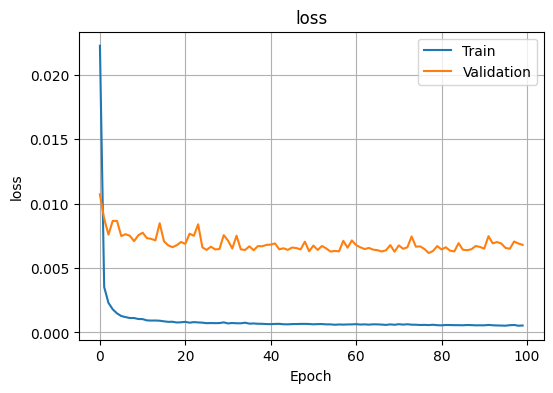

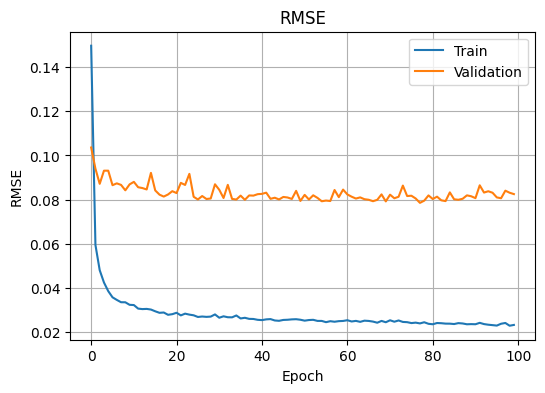

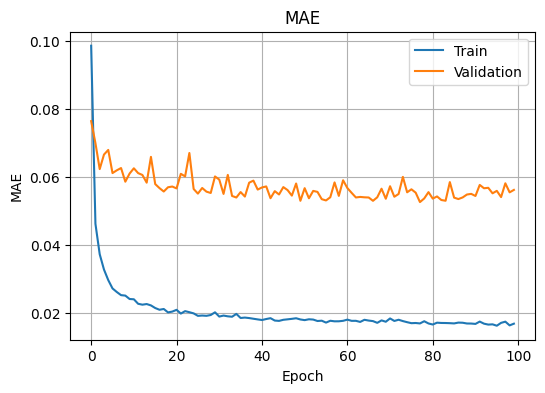

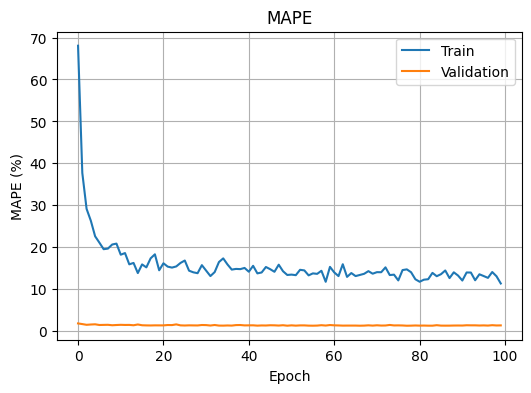

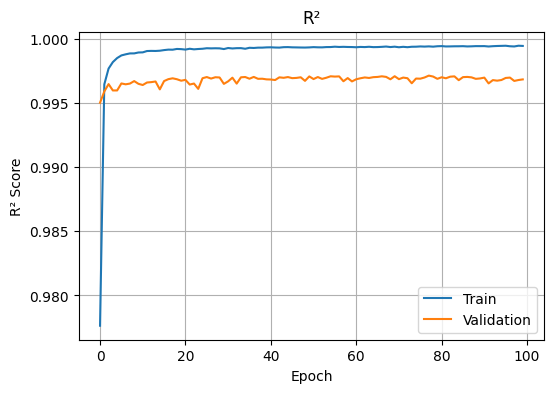

In [145]:
plot_metric(gru_history, "train_loss", "val_loss", "loss", "loss")
plot_metric(gru_history, "train_rmse", "val_rmse", "RMSE", "RMSE")
plot_metric(gru_history, "train_mae",  "val_mae",  "MAE",  "MAE")
plot_metric(gru_history, "train_mape","val_mape","MAPE","MAPE (%)")
plot_metric(gru_history, "train_r2",  "val_r2",  "R²",   "R² Score")


In [146]:
summary(
    gru_model,
    input_size=(1, SEQ_LEN, NUM_FEATURES),
    device=device
)


Layer (type:depth-idx)                   Output Shape              Param #
CNN_GRU                                  [1, 4]                    --
├─Conv1d: 1-1                            [1, 64, 9]                1,984
├─BatchNorm1d: 1-2                       [1, 64, 9]                128
├─ReLU: 1-3                              [1, 64, 9]                --
├─GRU: 1-4                               [1, 9, 64]                49,920
├─BatchNorm1d: 1-5                       [1, 64]                   128
├─Linear: 1-6                            [1, 4]                    260
Total params: 52,420
Trainable params: 52,420
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.47
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.21
Estimated Total Size (MB): 0.22

# 2-4


## 2-4-1

In [147]:
import torch
import numpy as np
import pandas as pd



def calculate_metrics_torch(y_true, y_pred):
    return {
        "RMSE": rmse(y_pred, y_true).item(),
        "MAE": mae(y_pred, y_true).item(),
        "MAPE": mape(y_pred, y_true).item(),
        "R2": r2_score_t(y_pred, y_true).item()
    }

def get_num_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



def evaluate_model_on_test(model, test_loader, device, criterion):
    model.eval()

    y_preds = []
    y_trues = []
    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            y_hat = model(x)

            loss = criterion(y_hat, y)
            total_loss += loss.item()
            num_batches += 1

            y_preds.append(y_hat.cpu())
            y_trues.append(y.cpu())

    y_pred = torch.cat(y_preds, dim=0)
    y_true = torch.cat(y_trues, dim=0)

    avg_loss = total_loss / num_batches

    return y_true, y_pred, avg_loss


criterion = torch.nn.MSELoss()   # همان loss آموزش

models_to_evaluate = {
    "Baseline MLP": mlp_model,
    "CNN-LSTM": lstm_model,
    "CNN-GRU": gru_model
}

results_list = []

print("Starting evaluation on Test Data...\n")

for model_name, model in models_to_evaluate.items():

    # Predictions + loss
    y_true, y_pred, test_loss = evaluate_model_on_test(
        model=model,
        test_loader=test_loader,
        device=device,
        criterion=criterion
    )

    # Metrics
    metrics = calculate_metrics_torch(y_true, y_pred)

    # Params
    num_params = get_num_parameters(model)

    # Save
    results_list.append({
        "Model": model_name,
        "Parameters": num_params,
        "Test Loss (MSE)": round(test_loss, 6),
        "R2 Score": round(metrics["R2"], 4),
        "MAPE (%)": round(metrics["MAPE"], 4),
        "MAE": round(metrics["MAE"], 4),
        "RMSE": round(metrics["RMSE"], 4)
    })


comparison_df = pd.DataFrame(results_list)
comparison_df.set_index("Model", inplace=True)

print("=" * 60)
print("جدول مقایسه عملکرد مدل‌ها روی داده‌های تست–)")
print("=" * 60)
print(comparison_df)
print("=" * 60)

comparison_df


Starting evaluation on Test Data...

جدول مقایسه عملکرد مدل‌ها روی داده‌های تست–)
              Parameters  Test Loss (MSE)  R2 Score  MAPE (%)     MAE    RMSE
Model                                                                        
Baseline MLP       20548         0.025349    0.9917    1.2796  0.1159  0.1572
CNN-LSTM           69060         0.008959    0.9969    0.7266  0.0644  0.0961
CNN-GRU            52420         0.009113    0.9969    0.7156  0.0635  0.0966


,Parameters,Test Loss (MSE),R2 Score,MAPE (%),MAE,RMSE
Model,,,,,,
Baseline MLP,20548,0.025349,0.9917,1.2796,0.1159,0.1572
CNN-LSTM,69060,0.008959,0.9969,0.7266,0.0644,0.0961
CNN-GRU,52420,0.009113,0.9969,0.7156,0.0635,0.0966


## 2-4-2

In [148]:
import torch.nn as nn
import math

def estimate_flops(model, seq_len, input_features):
    flops = 0
    current_seq_len = seq_len
    current_features = input_features
    
    # We maintain a history to handle simple skip connections manually if needed,
    # but for a static analyzer, we assume a sequential flow.
    
    for layer in model.modules():
        
        # -------- Linear --------
        if isinstance(layer, nn.Linear):
            # If the Linear layer consumes the "current_features", we assume it's connected
            # If dimensions mismatch, this static analyzer is drifting from reality.
            
            # FLOPs = 2 * In * Out * SeqLen
            flops += 2 * layer.in_features * layer.out_features * current_seq_len
            current_features = layer.out_features

        # -------- Conv1D --------
        elif isinstance(layer, nn.Conv1d):
            k = layer.kernel_size[0]
            s = layer.stride[0]
            d = layer.dilation[0]
            g = layer.groups

            # Padding logic
            padding = 0
            if layer.padding == "same":
                padding = (k - 1) * d // 2 # Integer approx
            elif isinstance(layer.padding, tuple):
                padding = layer.padding[0]
            else:
                padding = layer.padding

            # Output length formula
            out_len = math.floor(
                (current_seq_len + 2 * padding - d * (k - 1) - 1) / s + 1
            )

            flops += (2 * layer.in_channels * layer.out_channels * k * out_len) // g
            
            current_seq_len = out_len
            current_features = layer.out_channels

        # -------- Standard Pooling (FIXED) --------
        elif isinstance(layer, (nn.AvgPool1d, nn.MaxPool1d)):
            k = layer.kernel_size if isinstance(layer.kernel_size, int) else layer.kernel_size[0]
            s = layer.stride if isinstance(layer.stride, int) else layer.stride[0]
            pad = layer.padding if isinstance(layer.padding, int) else layer.padding[0]
            
            # Pooling reduces Sequence Length, it does not flatten!
            out_len = math.floor((current_seq_len + 2 * pad - k) / s + 1)
            current_seq_len = out_len
            # Features remain the same in pooling
            
        # -------- Global Pooling / Flatten --------
        elif isinstance(layer, (nn.AdaptiveAvgPool1d, nn.AdaptiveMaxPool1d)):
            # Adaptive pool usually forces size to 1 (Global Average Pooling)
            if layer.output_size == 1 or layer.output_size == (1,):
                current_seq_len = 1
                
        elif isinstance(layer, nn.Flatten):
            # If flattening, Sequence length effectively merges with Features or becomes 1
            # For FLOPs calculation of subsequent Linear layers, we usually treat 
            # the result as a vector.
            # New features = Old features * Old Seq Len
            current_features = current_features * current_seq_len
            current_seq_len = 1

        # -------- RNNs --------
        elif isinstance(layer, (nn.LSTM, nn.GRU)):
            is_lstm = isinstance(layer, nn.LSTM)
            D = layer.input_size
            H = layer.hidden_size
            L = layer.num_layers
            dirs = 2 if layer.bidirectional else 1
            mult = 8 if is_lstm else 6

            flops += L * dirs * current_seq_len * mult * H * (H + D)
            current_features = H * dirs

    return flops

In [149]:

results = []

results.append({
    "Model": "Baseline MLP",
    "Parameters": get_num_parameters(mlp_model),
    "Estimated FLOPs": estimate_flops(mlp_model, SEQ_LEN, "MLP"),
    "Training Time (s)": round(time_mlp, 2)
})

results.append({
    "Model": "CNN-LSTM",
    "Parameters": get_num_parameters(lstm_model),
    "Estimated FLOPs": estimate_flops(lstm_model, SEQ_LEN, "CNN-LSTM"),
    "Training Time (s)": round(time_lstm, 2)
})

results.append({
    "Model": "CNN-GRU",
    "Parameters": get_num_parameters(gru_model),
    "Estimated FLOPs": estimate_flops(gru_model, SEQ_LEN, "CNN-GRU"),
    "Training Time (s)": round(time_gru, 2)
})


df_efficiency = pd.DataFrame(results)
df_efficiency.set_index("Model", inplace=True)

# نمایش خواناتر
df_efficiency["Parameters"] = df_efficiency["Parameters"].map(lambda x: f"{x:,}")
df_efficiency["Estimated FLOPs"] = df_efficiency["Estimated FLOPs"].map(lambda x: f"{x:,}")

print("=" * 70)
print("Computational Efficiency Comparison")
print("=" * 70)
print(df_efficiency)
print("=" * 70)



Computational Efficiency Comparison
             Parameters Estimated FLOPs  Training Time (s)
Model                                                     
Baseline MLP     20,548          39,936              19.73
CNN-LSTM         69,060       1,218,816              30.61
CNN-GRU          52,420         923,904              28.86


## 2-4-3

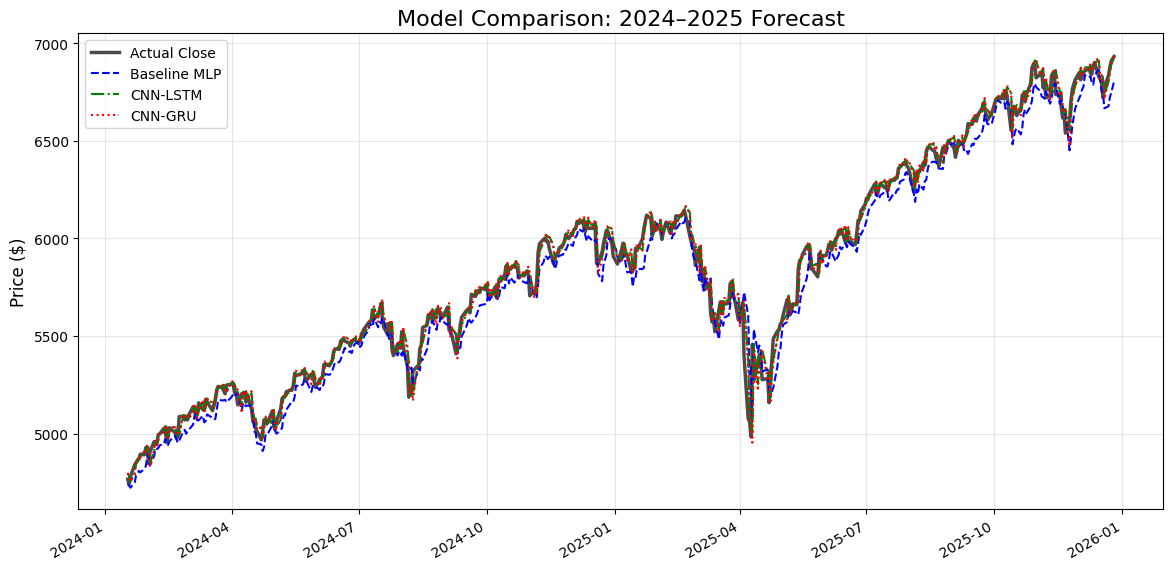

In [150]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Define your models here
models_dict = {
    "Baseline MLP": mlp_model,
    "CNN-LSTM": lstm_model, # Assuming you have this defined
    "CNN-GRU": gru_model    # Assuming you have this defined
}

# Store results
all_preds = {}
y_trues = [] # We only need to store True values once

# 1. Loop through all models
for name, model in models_dict.items():
    model.eval()
    temp_preds = []
    temp_trues = []
    
    with torch.no_grad():
        for x, y in last_year_loader:
            x = x.to(device)
            y_hat = model(x)
            temp_preds.append(y_hat.cpu())
            
            # Store true values only on the first pass (MLP)
            if name == "Baseline MLP":
                y = y.to(device).squeeze(1)
                temp_trues.append(y.cpu())

    # Concatenate
    pred_tensor = torch.cat(temp_preds, dim=0).numpy()
    all_preds[name] = y_scaler.inverse_transform(pred_tensor)[:, 3] # Index 3 = Close

    if name == "Baseline MLP":
        true_tensor = torch.cat(temp_trues, dim=0).numpy()
        true_close_vals = y_scaler.inverse_transform(true_tensor)[:, 3]

# 2. Align Dates
# Ensure 'dates' matches the length of the predictions
# (Assuming df_test_2024 covers the exact same range as last_year_loader)
dates = df_test_2024["Date"].iloc[-len(true_close_vals):].reset_index(drop=True)

# 3. Plot All Models together
plt.figure(figsize=(14, 7))

# Plot Actual
plt.plot(dates, true_close_vals, label="Actual Close", color="black", linewidth=2.5, alpha=0.7)

# Plot Predictions
colors = {'Baseline MLP': 'blue', 'CNN-LSTM': 'green', 'CNN-GRU': 'red'}
styles = {'Baseline MLP': '--', 'CNN-LSTM': '-.', 'CNN-GRU': ':'}

for name, pred_vals in all_preds.items():
    plt.plot(dates, pred_vals, label=name, color=colors.get(name, 'blue'), linestyle=styles.get(name, '-'))

plt.title("Model Comparison: 2024–2025 Forecast", fontsize=16)
plt.ylabel("Price ($)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

Starting Recursive Prediction for 365 days (2025-2026)...
Processing Baseline MLP...
Processing CNN-LSTM...
Processing CNN-GRU...


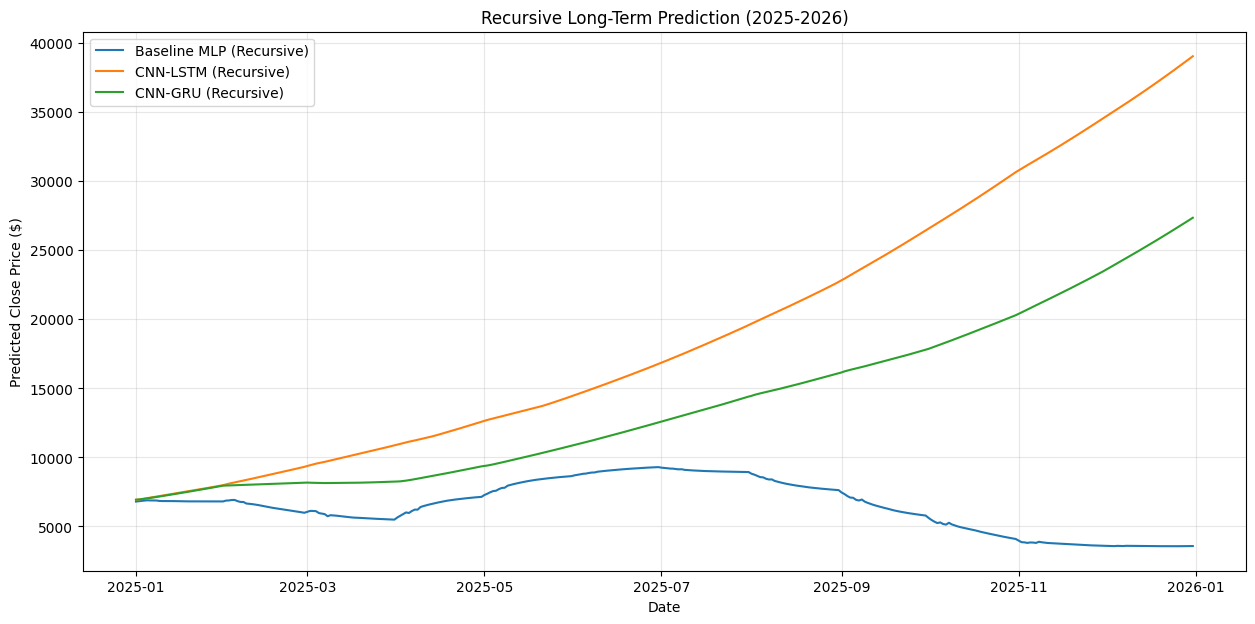


Analysis:
This plot demonstrates the limitations of recursive deep learning models.
Over a long horizon (2 years), errors accumulate, causing the prediction
to either flatten out to the mean or diverge significantly from realistic trends.


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# ==========================================
# 1. Helper Function: Cyclical Date Features
# ==========================================
def get_cyclical_features(date_obj):
    """Generates the 4 cyclical date features for a given timestamp."""
    day_of_year = date_obj.dayofyear
    month = date_obj.month
    
    # Must match training data logic
    day_sin = np.sin(2 * np.pi * day_of_year / 31)
    day_cos = np.cos(2 * np.pi * day_of_year / 31)
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    
    return np.array([day_sin, day_cos, month_sin, month_cos])

# ==========================================
# 2. Recursive Prediction Logic (Dual Scaler)
# ==========================================
def recursive_predict_dual_scaler(model, initial_sequence, steps, x_scaler, y_scaler, start_date):
    model.eval()
    
    # current_seq shape: (1, Window_Size, Input_Features)
    current_seq = torch.tensor(initial_sequence, dtype=torch.float32).unsqueeze(0).to(device)
    
    predictions_raw = []
    current_date = start_date
    
    num_input_features = x_scaler.n_features_in_
    num_output_features = 4 # Open, High, Low, Close
    
    with torch.no_grad():
        for _ in range(steps):
            # A. Predict Step (Scaled)
            pred_z = model(current_seq) # Shape (1, 4)
            
            # B. Inverse Transform (Get Real Prices)
            pred_z_np = pred_z.cpu().numpy()
            pred_raw = y_scaler.inverse_transform(pred_z_np) # Shape (1, 4)
            
            # Store Close price (index 3)
            predictions_raw.append(pred_raw[0, 3])
            
            # C. Build Next Input Vector (Raw Domain)
            current_date += timedelta(days=1)
            date_feats = get_cyclical_features(current_date).reshape(1, 4)
            
            # 1. Start with predicted prices
            next_row_raw = pred_raw
            
            # 2. Handle Extra Features (e.g. Volume) if missing
            expected_feats = num_output_features + 4 # 4 Prices + 4 Date Feats
            if num_input_features > expected_feats:
                # Repeat the last known volume from the sequence
                last_step_z = current_seq[0, -1, :].cpu().numpy().reshape(1, -1)
                last_step_raw = x_scaler.inverse_transform(last_step_z)
                gap = num_input_features - expected_feats
                missing_feats = last_step_raw[:, 4 : 4+gap] 
                next_row_raw = np.hstack([next_row_raw, missing_feats])
            
            # 3. Append Date Features
            next_row_raw = np.hstack([next_row_raw, date_feats])
            
            # D. Scale Next Input (X Domain)
            next_row_z = x_scaler.transform(next_row_raw)
            next_row_tensor = torch.tensor(next_row_z, dtype=torch.float32).unsqueeze(1).to(device)
            
            # E. Update Sequence (Drop oldest, Add new)
            current_seq = torch.cat((current_seq[:, 1:, :], next_row_tensor), dim=1)
            
    return np.array(predictions_raw)

# ==========================================
# 3. Execution (2025 - 2026)
# ==========================================

# --- CONFIGURATION ---
# Start Date: Jan 1, 2025
start_date_future = pd.Timestamp("2025-01-01") 
days_to_predict = 365 

# --- INPUT SEQUENCE ---
# Using the LAST window from your 2024 dataset to start predicting 2025
last_sequence_data = X_2024_z[-1] 

models_dict = {
    "Baseline MLP": mlp_model,
    "CNN-LSTM": lstm_model,
    "CNN-GRU": gru_model
}

future_results = {}

print(f"Starting Recursive Prediction for {days_to_predict} days (2025-2026)...")

for name, model in models_dict.items():
    print(f"Processing {name}...")
    try:
        preds = recursive_predict_dual_scaler(
            model, 
            last_sequence_data, 
            days_to_predict, 
            x_scaler, 
            y_scaler, 
            start_date_future
        )
        future_results[name] = preds
    except Exception as e:
        print(f"Error in {name}: {e}")

# ==========================================
# 4. Plotting
# ==========================================
future_dates = [start_date_future + timedelta(days=i) for i in range(days_to_predict)]

plt.figure(figsize=(15, 7))

# Optional: Plot end of 2024 actual history if available
# plt.plot(dates_2024[-100:], close_2024[-100:], label="History (2024)", color='black')

for name, preds in future_results.items():
    plt.plot(future_dates, preds, label=f"{name} (Recursive)")

plt.title("Recursive Long-Term Prediction (2025-2026)")
plt.xlabel("Date")
plt.ylabel("Predicted Close Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nAnalysis:")
print("This plot demonstrates the limitations of recursive deep learning models.")
print("Over a long horizon (1 years), errors accumulate, causing the prediction")
print("to either flatten out to the mean or diverge significantly from realistic trends.")

# 2-5

In [152]:
class CNN_Only(nn.Module):
    def __init__(self, num_features, output_dim):
        super(CNN_Only, self).__init__()
        
        # Layer 1: Downsample (Frequency extraction)
        # Stride=2 reduces dimension by half
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=32, kernel_size=4, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(32)
        
        # Layer 2: Downsample (Higher level feature extraction)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        
        # Layer 3: Global Feature Aggregator (The Fix)
        # Instead of a hardcoded kernel size, this forces the time dimension to 1
        # This acts exactly like a kernel size equal to the input length.
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Layer 4: Final Projection (1x1 Convolution)
        # Maps 64 features to 4 outputs (Open, High, Low, Close)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=output_dim, kernel_size=1)
        
    def forward(self, x):
        # x shape: [Batch, Seq_Len, Features] -> [Batch, Features, Seq_Len]
        x = x.permute(0, 2, 1)
        
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        
        # Collapse time dimension: [Batch, 64, T] -> [Batch, 64, 1]
        x = self.global_pool(x)
        
        # Final Prediction: [Batch, 64, 1] -> [Batch, 4, 1]
        x = self.conv3(x)
        
        # Remove last dimension: [Batch, 4]
        return x.squeeze(-1)


In [153]:
cnn_model = CNN_Only(NUM_FEATURES, output_dim=OUTPUT_DIM)
print("\n--- Training CNN-Only ---")

cnn_model, cnn_history,time_cnn = train_model(
    cnn_model,
    train_loader,
    val_loader,
    num_epochs=100
)



--- Training CNN-Only ---
Epoch 010 | Train Loss 0.0253 | Val Loss 0.0478 | Val R² 0.978
Epoch 020 | Train Loss 0.0214 | Val Loss 0.0424 | Val R² 0.980
Epoch 030 | Train Loss 0.0163 | Val Loss 0.2428 | Val R² 0.888
Epoch 040 | Train Loss 0.0170 | Val Loss 0.1196 | Val R² 0.945
Epoch 050 | Train Loss 0.0121 | Val Loss 0.0177 | Val R² 0.992
Epoch 060 | Train Loss 0.0091 | Val Loss 0.1111 | Val R² 0.949
Epoch 070 | Train Loss 0.0065 | Val Loss 0.1423 | Val R² 0.934
Epoch 080 | Train Loss 0.0049 | Val Loss 0.0159 | Val R² 0.993
Epoch 090 | Train Loss 0.0033 | Val Loss 0.0217 | Val R² 0.990
Epoch 100 | Train Loss 0.0041 | Val Loss 0.0212 | Val R² 0.990


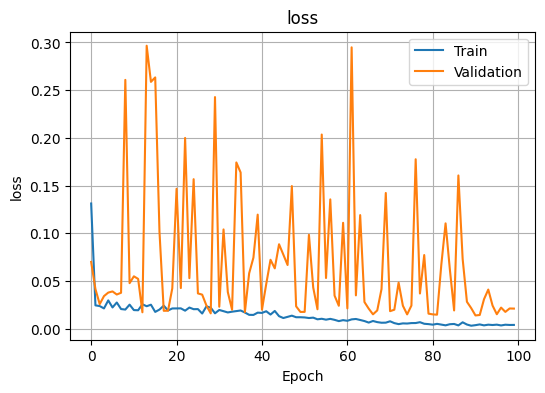

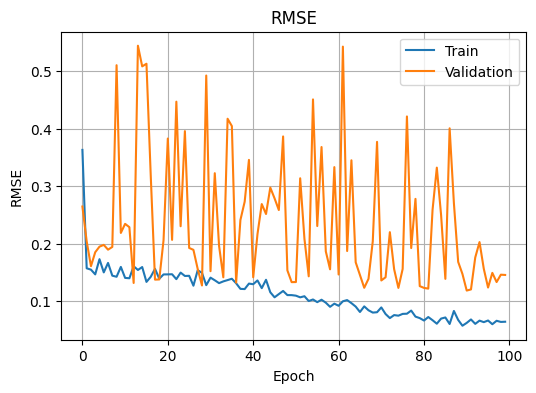

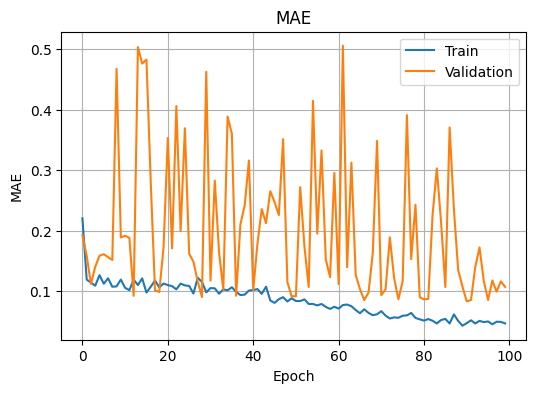

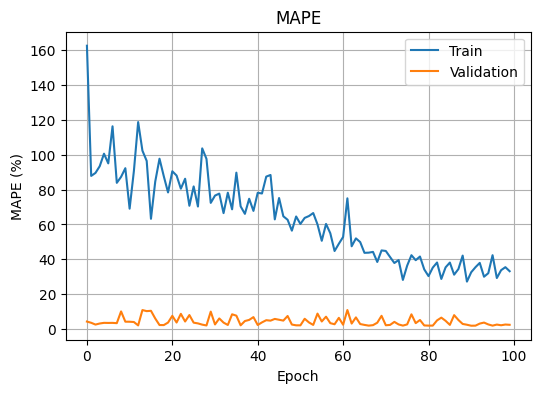

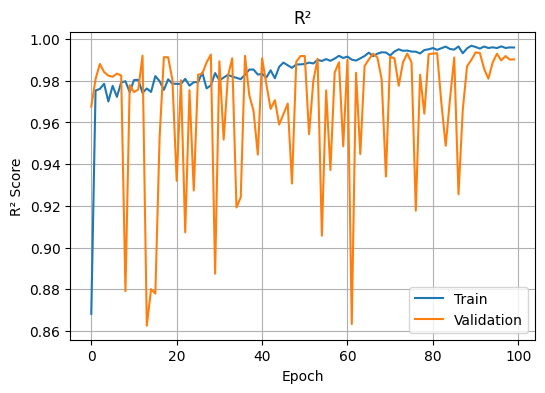

In [154]:
plot_metric(cnn_history, "train_loss", "val_loss", "loss", "loss")
plot_metric(cnn_history, "train_rmse", "val_rmse", "RMSE", "RMSE")
plot_metric(cnn_history, "train_mae",  "val_mae",  "MAE",  "MAE")
plot_metric(cnn_history, "train_mape","val_mape","MAPE","MAPE (%)")
plot_metric(cnn_history, "train_r2",  "val_r2",  "R²",   "R² Score")


In [155]:
summary(
    cnn_model,
    input_size=(1, SEQ_LEN, NUM_FEATURES),
    device=device
)

Layer (type:depth-idx)                   Output Shape              Param #
CNN_Only                                 [1, 4]                    --
├─Conv1d: 1-1                            [1, 32, 4]                1,312
├─BatchNorm1d: 1-2                       [1, 32, 4]                64
├─ReLU: 1-3                              [1, 32, 4]                --
├─Conv1d: 1-4                            [1, 64, 2]                8,256
├─BatchNorm1d: 1-5                       [1, 64, 2]                128
├─ReLU: 1-6                              [1, 64, 2]                --
├─AdaptiveAvgPool1d: 1-7                 [1, 64, 1]                --
├─Conv1d: 1-8                            [1, 4, 1]                 260
Total params: 10,020
Trainable params: 10,020
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04

In [156]:
print(time_cnn)

20.65663743019104


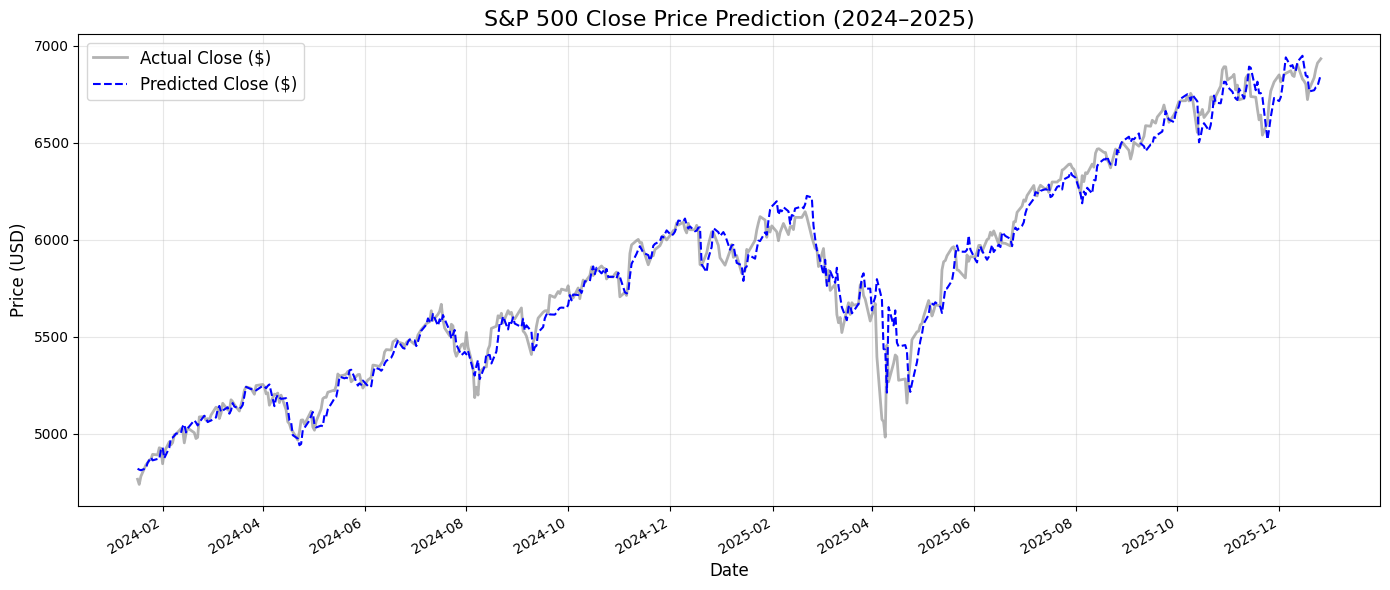

Samples plotted      : 489
Latest date          : 2025-12-26
Latest Actual Close  : $6932.05
Latest Pred Close    : $6850.80


In [157]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 1. Model Evaluation on Test (2024–2025)
# ==========================================
mlp_model.eval()

y_preds = []
y_trues = []

with torch.no_grad():
    for x, y in last_year_loader:
        x = x.to(device)
        y = y.to(device).squeeze(1)   # (B, 4)

        y_hat = cnn_model(x)          # (B, 4)

        y_preds.append(y_hat.cpu())
        y_trues.append(y.cpu())

# Concatenate batches
y_preds = torch.cat(y_preds, dim=0)  # (N, 4)
y_trues = torch.cat(y_trues, dim=0)  # (N, 4)

# ==========================================
# 2. Denormalize (Inverse Transform)
# ==========================================
# Convert to numpy for sklearn scaler
preds_scaled = y_preds.numpy()
trues_scaled = y_trues.numpy()

# Inverse scaling (expects shape [N, 4])
preds_real = y_scaler.inverse_transform(preds_scaled)
trues_real = y_scaler.inverse_transform(trues_scaled)

# Extract Close price (index 3)
pred_close = preds_real[:, 3]
true_close = trues_real[:, 3]

# ==========================================
# 3. Align Dates with Sliding Window Outputs
# ==========================================
# IMPORTANT:
# Each prediction corresponds to the END of a sliding window.
# Therefore, dates must be aligned to predictions.

# dates must come from the SAME df used to build last_year_loader
# Example:
dates = df_test_2024["Date"].reset_index(drop=True)

# Align length safely (robust to off-by-one)
dates = dates.iloc[-len(pred_close):]

# Final sanity check
assert len(dates) == len(pred_close), "Date / prediction length mismatch!"

# ==========================================
# 4. Plot: Actual vs Predicted Close (with Dates)
# ==========================================
plt.figure(figsize=(14, 6))

plt.plot(
    dates,
    true_close,
    label="Actual Close ($)",
    color="grey",
    alpha=0.6,
    linewidth=2
)

plt.plot(
    dates,
    pred_close,
    label="Predicted Close ($)",
    color="blue",
    linestyle="--",
    linewidth=1.5
)

plt.title("S&P 500 Close Price Prediction (2024–2025)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Beautify date axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

# ==========================================
# 5. Verification Prints
# ==========================================
print(f"Samples plotted      : {len(pred_close)}")
print(f"Latest date          : {dates.iloc[-1].date()}")
print(f"Latest Actual Close  : ${true_close[-1]:.2f}")
print(f"Latest Pred Close    : ${pred_close[-1]:.2f}")
